In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')
sys.path.insert(0, '../../../../../..')

# Decision labeling runtime models
import data_processing.decision_labeling
importlib.reload(data_processing.decision_labeling)
from data_processing.decision_labeling import DecisionLabeler

# Model
import suffix_pred.models.C_LSTM
importlib.reload(suffix_pred.models.C_LSTM)
from suffix_pred.models.C_LSTM import FullShared_Join_LSTM

# decision-rul guided decoding and reasoning
import suffix_pred.decision_rule_guided_reasoning_inference
importlib.reload(suffix_pred.decision_rule_guided_reasoning_inference)
from suffix_pred.decision_rule_guided_reasoning_inference import DecisionGuidanceConfig, get_decision_guided_evaluator

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import evaluate_dls, dls_per_prefix_length, average_dls

In [2]:
# Model
# Model clean:
file_path_model = '../../../../../../models/Sepsis/clean/Sepsis_C_LSTM_v1_clean.pkl'

# Model decision_train:
# file_path_model = '../../../../../../models/Sepsis/decision/Sepsis_C_LSTM_v1_DA.pkl'

model = FullShared_Join_LSTM.load(file_path_model)

# Load the data: Use for eval alway the clean test data:
file_path_test = '../../../../../../data/Sepsis/tensor_data/normal/sepsis_all_5_test.pkl'
test_dataset = torch.load(file_path_test, weights_only=False)

# Decision mining artifacts for runtime decision guidance
petri_net_path = '../../../../../../data/Sepsis/Petri_net/sepsis.pkl'
decision_bundle_path = '../../../../../../data/Sepsis/Petri_net/data_aware_Petri_net/decision_places_bundle.json'
decision_model_dir = '../../../../../../data/Sepsis/Petri_net/data_aware_Petri_net/models'

with open(petri_net_path, 'rb') as f:
    net, im, fm = pickle.load(f)

# Attributes must match decision model
dynamic_attributes = ["org:group",
                      "lifecycle:transition",
                      "case_elapsed_time",
                      "event_elapsed_time",
                      "Leucocytes",
                      "CRP",
                      "LacticAcid"]

# same across the whole trace
static_attributes = ["Age",
                     "InfectionSuspected",
                     "Diagnose",
                     "DiagnosticLacticAcid",
                     "DiagnosticBlood",
                     "DiagnosticArtAstrup",
                     "DiagnosticIC",
                     "DiagnosticSputum",
                     "DiagnosticLiquor",
                     "DiagnosticOther",
                     "DiagnosticUrinarySediment",
                     "DiagnosticECG",
                     "DiagnosticUrinaryCulture",
                     "DiagnosticXthorax",
                     "SIRSCritTachypnea",
                     "SIRSCritHeartRate",
                     "SIRSCriteria2OrMore",
                     "SIRSCritTemperature",
                     "SIRSCritLeucos",
                     "Hypotensie",
                     "Oligurie",
                     "Infusion",
                     "Hypoxie",
                     "DisfuncOrg"]

# 
decision_labeler = DecisionLabeler(petri_net=(net, im, fm),
                                   decision_model_dir=decision_model_dir,
                                   decision_places_bundle_path=decision_bundle_path,
                                   dynamic_attributes=dynamic_attributes,
                                   static_attributes=static_attributes)

# 
guidance_cfg = DecisionGuidanceConfig(epsilon=1e-3,
                                      beta_max=2.0,
                                      alpha=0.10,
                                      support_threshold=0.05)

print('Model and decision guidance artifacts loaded.')

Data set categories:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 28, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26, 'Y': 27}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Model input features:  [['concept:name', 'org:group'], ['case_elapsed_time']]


Embeddings:  ModuleList(
  (0): Embedding(18, 8)
  (1): Embedding(28, 10)
)
Total embedd

/home/PSPLab/.local/share/virtualenvs/decision_aware_augmentation_for_PPM-0DzgvVpC/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Model and decision guidance artifacts loaded.


In [3]:
# Step 1: Guided decode suffixes (mode / arg-max with local decision reweighting)
guided_mode_eval = get_decision_guided_evaluator(kind='mode',
                                                 model=model,
                                                 dataset=test_dataset,
                                                 decision_labeler=decision_labeler,
                                                 guidance_config=guidance_cfg,
                                                 decision_places_bundle_path=decision_bundle_path,
                                                 concept_name='concept:name',
                                                 eos_value='EOS')

guided_mode_outputs = []
guided_mode_reasoning = []

# evaluate the (decision) cases
for case_id, prefix_len, prefix, target_suffix, decoded_suffixes, reasoning in guided_mode_eval.evaluate(random_order=False,                                                                                                    return_reasoning=True):
    guided_mode_outputs.append({'case_id': case_id,
                                'prefix_len': int(prefix_len),
                                'prefix': prefix,
                                'target_suffix': target_suffix,
                                'decoded_suffixes': decoded_suffixes,
                                'mode': 'guided_mode'})
    
    guided_mode_reasoning.append({'case_id': case_id,
                                  'prefix_len': int(prefix_len),
                                  'reasoning': reasoning})

cache_outputs_path = '../../../../../../eval_results/Sepsis/decision_decoding/sepsis_c_lstm_decision_guided_outputs.pkl'
# cache_outputs_path = '../../../../../../eval_results/Sepsis/decision_train_and_decoding/sepsis_c_lstm_deciosn_train_and_decision_guided_mode_outputs.pkl'

cache_reasoning_path = '../../../../../../eval_results/Sepsis/decision_decoding/sepsis_c_lstm_decision_guided_reasoning.pkl'
# cache_reasoning_path = '../../../../../../eval_results/Sepsis/decision_train_and_decoding/sepsis_c_lstm_deciosn_train_and_decision_guided_mode_reasoning.pkl'
 
with open(cache_outputs_path, 'wb') as f:
    pickle.dump(guided_mode_outputs, f)

with open(cache_reasoning_path, 'wb') as f:
    pickle.dump(guided_mode_reasoning, f)

print(f"Decoded {len(guided_mode_outputs)} prefix rows in 'guided_mode'.")

# Step 2: Evaluate DLS from guided decoded outputs
guided_mode_df = evaluate_dls(guided_mode_outputs)
guided_mode_per_prefix = dls_per_prefix_length(guided_mode_df)
guided_mode_avg = average_dls(guided_mode_df)

# Step 3: Aggregate decision and explanation diagnostics
decision_steps = sum(r['reasoning']['decision_steps'] for r in guided_mode_reasoning)
conflicts = sum(r['reasoning']['conflicts'] for r in guided_mode_reasoning)
explained_steps = sum(r['reasoning'].get('explained_steps', 0) for r in guided_mode_reasoning)

conflict_rate = (conflicts / decision_steps) if decision_steps > 0 else 0.0
explained_rate = (explained_steps / decision_steps) if decision_steps > 0 else 0.0

print(f"Average DLS (guided_mode) on full test set: {guided_mode_avg:.4f}")
print(f"Decision steps: {decision_steps} | Conflicts: {conflicts} | Conflict rate: {conflict_rate:.4f}")
print(f"Explained steps: {explained_steps} | Explained rate: {explained_rate:.4f}")

  0%|          | 0/209 [00:00<?, ?it/s]

/home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/src/notebooks/suffix_prediction/evaluation/Sepsis/decision_decoding/../../../../../decision_mining/function_estimator_catboost_advanced.py:747: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_raw[col] = np.nan
/home/PSPLab/ProbabilisticSuffixPredictionLab/decision_aware_augmentation_for_PPM/src/notebooks/suffix_prediction/evaluation/Sepsis/decision_decoding/../../../../../decision_mining/function_estimator_catboost_advanced.py:747: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, us

Decoded 2648 prefix rows in 'guided_mode'.
Average DLS (guided_mode) on full test set: 0.3948
Decision steps: 23038 | Conflicts: 1761 | Conflict rate: 0.0764
Explained steps: 3767 | Explained rate: 0.1635


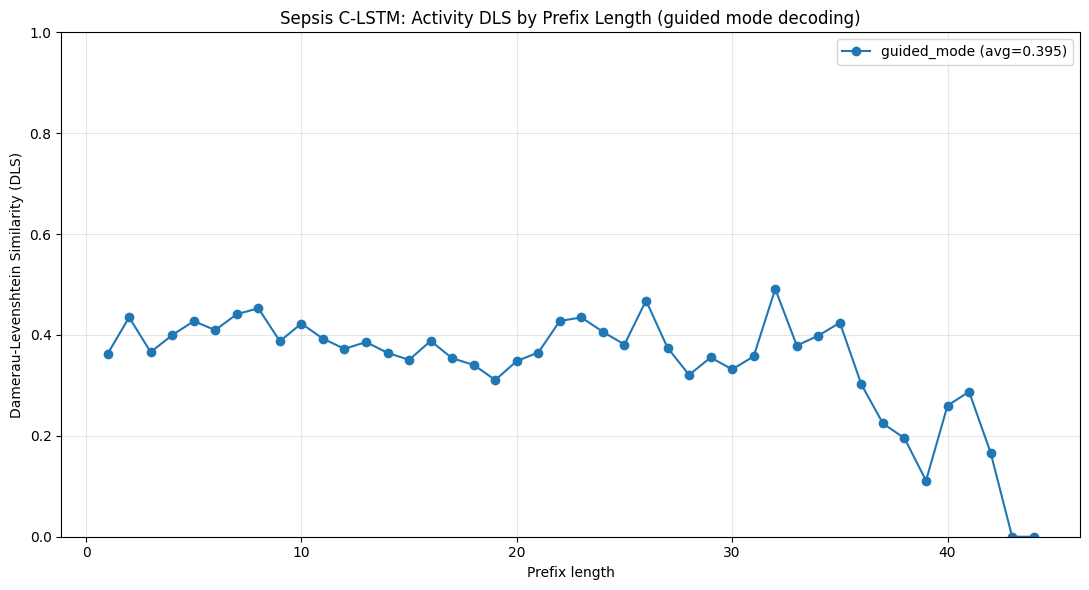

,mode,average_dls,decision_steps,conflicts,conflict_rate,explained_steps,explained_rate
0,guided_mode,0.394836,23038,1761,0.076439,3767,0.163512


In [4]:
# Plot DLS by prefix length for guided mode
plt.figure(figsize=(11, 6))

plt.plot(guided_mode_per_prefix['prefix_len'],
         guided_mode_per_prefix['dls'],
         marker='o',
         label=f"guided_mode (avg={guided_mode_avg:.3f})")

plt.title('Sepsis C-LSTM: Activity DLS by Prefix Length (guided mode decoding)')
plt.xlabel('Prefix length')
plt.ylabel('Damerau-Levenshtein Similarity (DLS)')
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'mode': ['guided_mode'],
    'average_dls': [guided_mode_avg],
    'decision_steps': [decision_steps],
    'conflicts': [conflicts],
    'conflict_rate': [conflict_rate],
    'explained_steps': [explained_steps],
    'explained_rate': [explained_rate],
}).sort_values('average_dls', ascending=False).reset_index(drop=True)
summary

In [5]:
# Inspect guided predictions and rule-based reasoning examples with per-attribute checks
with open('../../../../../../eval_results/Sepsis/decision_decoding/sepsis_c_lstm_decision_guided_outputs.pkl', 'rb') as f:
    cached_outputs = pickle.load(f)
    
with open('../../../../../../eval_results/Sepsis/decision_decoding/sepsis_c_lstm_decision_guided_reasoning.pkl', 'rb') as f:
    cached_reasoning = pickle.load(f)

for i in range(min(100, len(cached_outputs))):
    row = cached_outputs[i]
    reason = cached_reasoning[i]['reasoning']

    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:            {row['prefix']}")
    print(f"  Target suffix:     {row['target_suffix']}")
    decoded = row['decoded_suffixes']
    print(f"  Predicted suffix:  {decoded[0] if len(decoded) > 0 else []}")
    print(f"  Decision steps: {reason['decision_steps']} | Conflicts: {reason['conflicts']} | Conflict rate: {reason['conflict_rate']:.4f}")
    print(f"  Explained steps: {reason.get('explained_steps', 0)} | Explained rate: {reason.get('explained_rate', 0.0):.4f}")

    trace = reason.get('trace', [])
    if len(trace) == 0:
        print("  No supported rule-aligned reasoning step.")
        print()
        continue

    for step in trace[:3]:
        decision_top = step.get('decision_top_event')
        decision_top_prob = step.get('decision_top_prob')
        next_event = step['next_event']
        model_prob = step.get('model_prob')
        model_prob_str = f"{model_prob:.1%}" if model_prob is not None else "?"

        if decision_top is not None and decision_top != next_event:
            # Decision model's top pick differs from what the suffix predictor chose
            top_prob_str = f"p={decision_top_prob:.1%}" if decision_top_prob is not None else "p=?"
            print(f"  Decision step {step['step']}: {step['input_event']} -> "
                  f"{decision_top} ({top_prob_str}, decision top) at place {step['place']}, "
                  f"but with prob {model_prob_str} (model), {next_event} was predicted")
        else:
            top_prob_str = f", decision top p={decision_top_prob:.1%}" if decision_top_prob is not None else ""
            print(f"  Decision step {step['step']}: {step['input_event']} -> "
                  f"{next_event} (model prob: {model_prob_str}{top_prob_str}) at place {step['place']}")

        matched_rule = step.get('matched_rule')
        if matched_rule is not None:
            print(f"    Matched rule: {matched_rule.get('rule', '')}")

        attr_checks = step.get('attribute_checks', [])
        seen_attrs = set()
        if len(attr_checks) == 0:
            print("    No attribute checks available.")
        else:
            for chk in attr_checks:
                attr_name = chk.get('attr', '')
                attr_value = chk.get('value', None)
                dedup_key = (attr_name, attr_value)
                if dedup_key in seen_attrs:
                    continue
                seen_attrs.add(dedup_key)
                is_in_rule = bool(chk.get('in_rule_set', False))
                print(f"    - {attr_name}: value={attr_value} | in_rule_set={is_in_rule}")
    print()


Case: AAA  |  Prefix len: 1
  Prefix:            ['ER Registration']
  Target suffix:     ['ER Triage', 'ER Sepsis Triage', 'IV Liquid', 'Leucocytes', 'CRP', 'LacticAcid', 'IV Antibiotics', 'Admission NC', 'Release A', 'Return ER']
  Predicted suffix:  ['ER Sepsis Triage', 'CRP', 'Leucocytes', 'LacticAcid', 'CRP', 'Leucocytes', 'Admission NC', 'Admission NC', 'Leucocytes']
  Decision steps: 8 | Conflicts: 1 | Conflict rate: 0.1250
  Explained steps: 3 | Explained rate: 0.3750
  Decision step 1: ER Sepsis Triage -> IV Antibiotics (p=31.8%, decision top) at place p_49, but with prob 61.8% (model), CRP was predicted
    No attribute checks available.
  Decision step 2: CRP -> Leucocytes (model prob: 58.6%, decision top p=35.1%) at place p_27
    Matched rule: (org:group_prev3 in {A, B, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S} (+4 more)) AND (case_elapsed_time_older_std <= 606573) AND (case_elapsed_time_prev1 <= 44706) AND (event_elapsed_time_prev3 <= 404294) AND (org:group_older_no